In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "../data/churn_training_final.csv"

df = pd.read_csv(path)

print(df.shape)
print(df.columns.tolist())
df.head()

(32897, 24)
['account_id', 'observation_date', 'is_churn', 'channel', 'country', 'customer_age', 'account_tenure_days', 'post_per_month', 'newfriend_per_month', 'like_per_month', 'adview_per_month', 'dislike_per_month', 'unfriend_per_month', 'message_per_month', 'reply_per_month', 'current_plan', 'current_mrr', 'bill_period_months', 'discount', 'mrr_change', 'upgrade_flag', 'downsell_flag', 'upgrade_last_90d', 'downsell_last_90d']


,account_id,observation_date,is_churn,channel,country,customer_age,account_tenure_days,post_per_month,newfriend_per_month,like_per_month,...,reply_per_month,current_plan,current_mrr,bill_period_months,discount,mrr_change,upgrade_flag,downsell_flag,upgrade_last_90d,downsell_last_90d
0,0,2020-03-05,f,appstore2,NaN,74,53,5,3,146,...,9,basic,10.0,1,0.0,0.0,0,0,0,0
1,0,2020-04-05,f,appstore2,NaN,74,84,6,2,140,...,5,basic,10.0,1,0.0,0.0,0,0,0,0
2,0,2020-05-05,f,appstore2,NaN,75,114,7,3,141,...,7,basic,10.0,1,0.0,0.0,0,0,0,0
3,1,2020-03-08,f,appstore1,AU,64,53,30,5,19,...,5,basic,10.0,1,0.0,0.0,0,0,0,0
4,1,2020-04-08,f,appstore1,AU,64,84,37,8,21,...,2,basic,10.0,1,0.0,0.0,0,0,0,0


In [14]:
df["observation_date"] = pd.to_datetime(df["observation_date"])

df["country"] = df["country"].fillna("Unknown")

df["is_churn"] = (
    df["is_churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "t": 1,
        "true": 1,
        "1": 1,
        "f": 0,
        "false": 0,
        "0": 0
    })
)

In [18]:
print(df["observation_date"].min())
print(df["observation_date"].max())
print(df["observation_date"].nunique())

2020-02-09 00:00:00
2020-05-10 00:00:00
92


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32897 entries, 0 to 32896
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   account_id           32897 non-null  int64  
 1   observation_date     32897 non-null  object 
 2   is_churn             32897 non-null  object 
 3   channel              32897 non-null  object 
 4   country              29181 non-null  object 
 5   customer_age         32897 non-null  int64  
 6   account_tenure_days  32897 non-null  int64  
 7   post_per_month       32897 non-null  int64  
 8   newfriend_per_month  32897 non-null  int64  
 9   like_per_month       32897 non-null  int64  
 10  adview_per_month     32897 non-null  int64  
 11  dislike_per_month    32897 non-null  int64  
 12  unfriend_per_month   32897 non-null  int64  
 13  message_per_month    32897 non-null  int64  
 14  reply_per_month      32897 non-null  int64  
 15  current_plan         32897 non-null 

In [3]:
df["is_churn"].value_counts()

is_churn
f    32252
t      645
Name: count, dtype: int64

In [4]:
df["is_churn"].value_counts(normalize=True)

is_churn
f    0.980393
t    0.019607
Name: proportion, dtype: float64

In [5]:
df.isna().sum().sort_values(ascending=False)

country                3716
account_id                0
message_per_month         0
upgrade_last_90d          0
downsell_flag             0
upgrade_flag              0
mrr_change                0
discount                  0
bill_period_months        0
current_mrr               0
current_plan              0
reply_per_month           0
unfriend_per_month        0
observation_date          0
dislike_per_month         0
adview_per_month          0
like_per_month            0
newfriend_per_month       0
post_per_month            0
account_tenure_days       0
customer_age              0
channel                   0
is_churn                  0
downsell_last_90d         0
dtype: int64

In [6]:
df.duplicated(
    subset=["account_id", "observation_date"]
).sum()

np.int64(0)

In [10]:
df["is_churn"] = (
    df["is_churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "t": 1,
        "true": 1,
        "1": 1,
        "f": 0,
        "false": 0,
        "0": 0
    })
)

In [11]:
print(df["is_churn"].dtype)
print(df["is_churn"].value_counts())
print(df["is_churn"].isna().sum())

int64
is_churn
0    32252
1      645
Name: count, dtype: int64
0


In [12]:
(
    df.groupby("current_plan")["is_churn"]
      .agg(["count", "mean"])
      .sort_values("mean", ascending=False)
)

,count,mean
current_plan,,
basic,20457,0.020531
plus,9322,0.018558
premium,3118,0.016677


In [13]:
(
    df.groupby("downsell_last_90d")["is_churn"]
      .agg(["count", "mean"])
)

,count,mean
downsell_last_90d,,
0,32364,0.019775
1,533,0.009381


In [19]:
# Churn by billing period
df.groupby("bill_period_months")["is_churn"].agg(
    observations="count",
    churn_rate="mean"
)

,observations,churn_rate
bill_period_months,,
1,19765,0.019125
3,9835,0.019217
6,3297,0.023658


In [20]:
# Churn by upgrade history
df.groupby("upgrade_last_90d")["is_churn"].agg(
    observations="count",
    churn_rate="mean"
)

,observations,churn_rate
upgrade_last_90d,,
0,32344,0.019880
1,553,0.003617


In [21]:
# Churn counts as well as rates for downsells
df.groupby("downsell_last_90d")["is_churn"].agg(
    observations="count",
    churns="sum",
    churn_rate="mean"
)

,observations,churns,churn_rate
downsell_last_90d,,,
0,32364,640,0.019775
1,533,5,0.009381


In [22]:
eps = 1e-6

df["dislike_rate"] = (
    df["dislike_per_month"]
    / (df["like_per_month"] + df["dislike_per_month"] + eps)
)

df["unfriend_rate"] = (
    df["unfriend_per_month"]
    / (df["newfriend_per_month"] + df["unfriend_per_month"] + eps)
)

df["reply_rate"] = (
    df["reply_per_month"]
    / (df["message_per_month"] + eps)
)

df["total_engagement"] = (
    df["post_per_month"]
    + df["newfriend_per_month"]
    + df["like_per_month"]
    + df["message_per_month"]
    + df["reply_per_month"]
)

In [23]:
# engineer your behavioral features

import numpy as np

# Ratios - use np.where to handle zero denominators cleanly
df["dislike_rate"] = np.where(
    (df["like_per_month"] + df["dislike_per_month"]) > 0,
    df["dislike_per_month"] /
    (df["like_per_month"] + df["dislike_per_month"]),
    0
)

df["unfriend_rate"] = np.where(
    (df["newfriend_per_month"] + df["unfriend_per_month"]) > 0,
    df["unfriend_per_month"] /
    (df["newfriend_per_month"] + df["unfriend_per_month"]),
    0
)

df["reply_rate"] = np.where(
    df["message_per_month"] > 0,
    df["reply_per_month"] / df["message_per_month"],
    0
)

# Overall positive activity
df["total_engagement"] = (
    df["post_per_month"]
    + df["newfriend_per_month"]
    + df["like_per_month"]
    + df["message_per_month"]
    + df["reply_per_month"]
)

# Negative social actions
df["negative_engagement"] = (
    df["dislike_per_month"]
    + df["unfriend_per_month"]
)

df[
    [
        "dislike_rate",
        "unfriend_rate",
        "reply_rate",
        "total_engagement",
        "negative_engagement"
    ]
].describe()

,dislike_rate,unfriend_rate,reply_rate,total_engagement,negative_engagement
count,32897.000000,32897.000000,32897.000000,32897.000000,32897.000000
mean,0.231836,0.081145,0.384484,214.312065,15.249567
std,0.209222,0.197645,0.336640,304.261499,21.720584
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.071429,0.000000,0.166667,64.000000,4.000000
50%,0.166667,0.000000,0.348039,127.000000,9.000000
75%,0.333333,0.040000,0.500000,247.000000,18.000000
max,1.000000,1.000000,9.000000,7109.000000,429.000000


In [24]:
features = [
    "total_engagement",
    "negative_engagement",
    "dislike_rate",
    "unfriend_rate",
    "reply_rate",
    "account_tenure_days"
]

df.groupby("is_churn")[features].median().T

is_churn,0,1
total_engagement,128.000000,61.000000
negative_engagement,9.000000,6.000000
dislike_rate,0.166667,0.207547
unfriend_rate,0.000000,0.000000
reply_rate,0.350000,0.272727
account_tenure_days,53.000000,53.000000


In [25]:
# ============================================================
# CHURN PREDICTION PROJECT
# EDA + FEATURE ENGINEERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [27]:
# Convert observation date
df["observation_date"] = pd.to_datetime(df["observation_date"])

# Convert churn target to:
# 0 = retained
# 1 = churn
df["is_churn"] = (
    df["is_churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "t": 1,
        "true": 1,
        "1": 1,
        "f": 0,
        "false": 0,
        "0": 0
    })
)

# Missing country becomes its own category
df["country"] = df["country"].fillna("Unknown")

In [28]:
# ============================================================
# 3. DATA VALIDATION
# ============================================================

print("\n--- DATA INFO ---")
df.info()

print("\n--- DATE RANGE ---")
print("Start:", df["observation_date"].min())
print("End:", df["observation_date"].max())
print("Distinct observation dates:", df["observation_date"].nunique())

print("\n--- TARGET ---")
print(df["is_churn"].value_counts())

print("\n--- TARGET % ---")
print((df["is_churn"].value_counts(normalize=True) * 100).round(2))

print("\n--- MISSING VALUES ---")
print(df.isna().sum().sort_values(ascending=False))

print("\n--- DUPLICATE CUSTOMER-DATE ROWS ---")
duplicates = df.duplicated(
    subset=["account_id", "observation_date"]
).sum()

print(duplicates)

print("\n--- UNIQUE ACCOUNTS ---")
print(df["account_id"].nunique())



--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32897 entries, 0 to 32896
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   account_id           32897 non-null  int64         
 1   observation_date     32897 non-null  datetime64[ns]
 2   is_churn             32897 non-null  int64         
 3   channel              32897 non-null  object        
 4   country              32897 non-null  object        
 5   customer_age         32897 non-null  int64         
 6   account_tenure_days  32897 non-null  int64         
 7   post_per_month       32897 non-null  int64         
 8   newfriend_per_month  32897 non-null  int64         
 9   like_per_month       32897 non-null  int64         
 10  adview_per_month     32897 non-null  int64         
 11  dislike_per_month    32897 non-null  int64         
 12  unfriend_per_month   32897 non-null  int64         
 13  message_per_

In [29]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

# ------------------------------------------------------------
# Positive engagement
# ------------------------------------------------------------

df["total_engagement"] = (
    df["post_per_month"]
    + df["newfriend_per_month"]
    + df["like_per_month"]
    + df["message_per_month"]
    + df["reply_per_month"]
)

In [30]:
# ------------------------------------------------------------
# Negative engagement
# ------------------------------------------------------------

df["negative_engagement"] = (
    df["dislike_per_month"]
    + df["unfriend_per_month"]
)



In [31]:
# ------------------------------------------------------------
# Total social activity
# Includes positive + negative + ad views
# ------------------------------------------------------------

df["total_activity"] = (
    df["post_per_month"]
    + df["newfriend_per_month"]
    + df["like_per_month"]
    + df["adview_per_month"]
    + df["dislike_per_month"]
    + df["unfriend_per_month"]
    + df["message_per_month"]
    + df["reply_per_month"]
)

In [32]:

# ------------------------------------------------------------
# Dislike rate
# dislikes relative to likes + dislikes
# bounded between 0 and 1
# ------------------------------------------------------------

df["dislike_rate"] = np.where(
    (df["like_per_month"] + df["dislike_per_month"]) > 0,
    df["dislike_per_month"] /
    (df["like_per_month"] + df["dislike_per_month"]),
    0
)



In [33]:

# ------------------------------------------------------------
# Unfriend rate
# unfriends relative to new friends + unfriends
# bounded between 0 and 1
# ------------------------------------------------------------

df["unfriend_rate"] = np.where(
    (df["newfriend_per_month"] + df["unfriend_per_month"]) > 0,
    df["unfriend_per_month"] /
    (df["newfriend_per_month"] + df["unfriend_per_month"]),
    0
)

In [34]:
# ------------------------------------------------------------
# Reply rate
# Note: replies/messages can exceed 1
# ------------------------------------------------------------

df["reply_rate"] = np.where(
    df["message_per_month"] > 0,
    df["reply_per_month"] / df["message_per_month"],
    0
)

In [35]:

# ------------------------------------------------------------
# Negative behavior share
# ------------------------------------------------------------

df["negative_activity_share"] = np.where(
    df["total_activity"] > 0,
    df["negative_engagement"] / df["total_activity"],
    0
)


In [36]:

# ------------------------------------------------------------
# Ad exposure share
# ------------------------------------------------------------

df["adview_share"] = np.where(
    df["total_activity"] > 0,
    df["adview_per_month"] / df["total_activity"],
    0
)

In [37]:
# ------------------------------------------------------------
# MRR movement direction
# -1 = downsell
#  0 = no MRR change
#  1 = upgrade
# ------------------------------------------------------------

df["mrr_change_direction"] = np.select(
    [
        df["mrr_change"] < 0,
        df["mrr_change"] > 0
    ],
    [
        -1,
        1
    ],
    default=0
)


In [38]:
# ------------------------------------------------------------
# Tenure groups for EDA only
# Keep raw tenure for modeling
# ------------------------------------------------------------

df["tenure_group"] = pd.cut(
    df["account_tenure_days"],
    bins=[-1, 30, 60, 90, 120, np.inf],
    labels=[
        "0-30 days",
        "31-60 days",
        "61-90 days",
        "91-120 days",
        "120+ days"
    ]
)


In [39]:

# ============================================================
# 5. FEATURE VALIDATION
# ============================================================

engineered_features = [
    "total_engagement",
    "negative_engagement",
    "total_activity",
    "dislike_rate",
    "unfriend_rate",
    "reply_rate",
    "negative_activity_share",
    "adview_share"
]

print("\n--- ENGINEERED FEATURE SUMMARY ---")

display(
    df[engineered_features]
    .describe()
    .T
)


--- ENGINEERED FEATURE SUMMARY ---


,count,mean,std,min,25%,50%,75%,max
total_engagement,32897.0,214.312065,304.261499,0.0,64.000000,127.000000,247.000000,7109.0000
negative_engagement,32897.0,15.249567,21.720584,0.0,4.000000,9.000000,18.000000,429.0000
total_activity,32897.0,266.548439,349.216313,1.0,87.000000,165.000000,312.000000,7575.0000
dislike_rate,32897.0,0.231836,0.209222,0.0,0.071429,0.166667,0.333333,1.0000
unfriend_rate,32897.0,0.081145,0.197645,0.0,0.000000,0.000000,0.040000,1.0000
reply_rate,32897.0,0.384484,0.336640,0.0,0.166667,0.348039,0.500000,9.0000
negative_activity_share,32897.0,0.078323,0.081610,0.0,0.024159,0.052265,0.104167,1.0000
adview_share,32897.0,0.144248,0.112365,0.0,0.060606,0.117647,0.200000,0.8125


In [40]:

# Check for infinity / NaN
print("\n--- INVALID VALUES ---")

for col in engineered_features:
    print(
        col,
        "NaN:",
        df[col].isna().sum(),
        "Inf:",
        np.isinf(df[col]).sum()
    )



--- INVALID VALUES ---
total_engagement NaN: 0 Inf: 0
negative_engagement NaN: 0 Inf: 0
total_activity NaN: 0 Inf: 0
dislike_rate NaN: 0 Inf: 0
unfriend_rate NaN: 0 Inf: 0
reply_rate NaN: 0 Inf: 0
negative_activity_share NaN: 0 Inf: 0
adview_share NaN: 0 Inf: 0


In [41]:
# ============================================================
# 6. OVERALL CHURN RATE
# ============================================================

overall_churn_rate = df["is_churn"].mean()

print(
    f"\nOverall churn rate: "
    f"{overall_churn_rate:.2%}"
)



Overall churn rate: 1.96%


In [42]:
# ============================================================
# 7. CHURN BY SUBSCRIPTION PLAN
# ============================================================

plan_churn = (
    df.groupby("current_plan", observed=True)["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
    .sort_values("churn_rate", ascending=False)
)

plan_churn["churn_rate_pct"] = (
    plan_churn["churn_rate"] * 100
)

print("\n--- CHURN BY PLAN ---")
display(plan_churn)


--- CHURN BY PLAN ---


,observations,churns,churn_rate,churn_rate_pct
current_plan,,,,
basic,20457,420,0.020531,2.053087
plus,9322,173,0.018558,1.855825
premium,3118,52,0.016677,1.667736


In [43]:

# ============================================================
# 8. CHURN BY BILLING PERIOD
# ============================================================

billing_churn = (
    df.groupby("bill_period_months", observed=True)["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

billing_churn["churn_rate_pct"] = (
    billing_churn["churn_rate"] * 100
)

print("\n--- CHURN BY BILLING PERIOD ---")
display(billing_churn)



--- CHURN BY BILLING PERIOD ---


,observations,churns,churn_rate,churn_rate_pct
bill_period_months,,,,
1,19765,378,0.019125,1.912472
3,9835,189,0.019217,1.921708
6,3297,78,0.023658,2.365787


In [44]:
# ============================================================
# 9. CHURN BY RECENT UPGRADE
# ============================================================

upgrade_churn = (
    df.groupby("upgrade_last_90d")["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

upgrade_churn["churn_rate_pct"] = (
    upgrade_churn["churn_rate"] * 100
)

print("\n--- CHURN BY RECENT UPGRADE ---")
display(upgrade_churn)



--- CHURN BY RECENT UPGRADE ---


,observations,churns,churn_rate,churn_rate_pct
upgrade_last_90d,,,,
0,32344,643,0.019880,1.988004
1,553,2,0.003617,0.361664


In [45]:
# ============================================================
# 10. CHURN BY RECENT DOWNSELL
# ============================================================

downsell_churn = (
    df.groupby("downsell_last_90d")["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

downsell_churn["churn_rate_pct"] = (
    downsell_churn["churn_rate"] * 100
)

print("\n--- CHURN BY RECENT DOWNSELL ---")
display(downsell_churn)


--- CHURN BY RECENT DOWNSELL ---


,observations,churns,churn_rate,churn_rate_pct
downsell_last_90d,,,,
0,32364,640,0.019775,1.977506
1,533,5,0.009381,0.938086


In [46]:
# ============================================================
# 11. CHURN BY CHANNEL
# ============================================================

channel_churn = (
    df.groupby("channel", observed=True)["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
    .sort_values("churn_rate", ascending=False)
)

channel_churn["churn_rate_pct"] = (
    channel_churn["churn_rate"] * 100
)

print("\n--- CHURN BY CHANNEL ---")
display(channel_churn)



--- CHURN BY CHANNEL ---


,observations,churns,churn_rate,churn_rate_pct
channel,,,,
web,4851,148,0.030509,3.050917
appstore1,9807,222,0.022637,2.263689
appstore2,18239,275,0.015078,1.507758


In [47]:
# ============================================================
# 12. CHURN BY TENURE GROUP
# ============================================================

tenure_churn = (
    df.groupby("tenure_group", observed=True)["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

tenure_churn["churn_rate_pct"] = (
    tenure_churn["churn_rate"] * 100
)

print("\n--- CHURN BY TENURE ---")
display(tenure_churn)


--- CHURN BY TENURE ---


,observations,churns,churn_rate,churn_rate_pct
tenure_group,,,,
0-30 days,7593,154,0.020282,2.028184
31-60 days,10824,288,0.026608,2.660754
61-90 days,9600,163,0.016979,1.697917
91-120 days,4880,40,0.008197,0.819672


In [48]:
# ============================================================
# 13. CHURN BY COUNTRY
# Only show countries with enough observations
# ============================================================

country_churn = (
    df.groupby("country", observed=True)["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

country_churn = (
    country_churn[
        country_churn["observations"] >= 100
    ]
    .sort_values(
        "churn_rate",
        ascending=False
    )
)

country_churn["churn_rate_pct"] = (
    country_churn["churn_rate"] * 100
)

print("\n--- CHURN BY COUNTRY ---")
display(country_churn)




--- CHURN BY COUNTRY ---


,observations,churns,churn_rate,churn_rate_pct
country,,,,
PT,259,8,0.030888,3.088803
CA,1320,34,0.025758,2.575758
IT,312,8,0.025641,2.564103
US,4900,116,0.023673,2.367347
CO,711,16,0.022504,2.250352
ID,321,7,0.021807,2.180685
NL,323,7,0.021672,2.167183
IN,1341,29,0.021626,2.162565
FR,1049,22,0.020972,2.097235


In [49]:
# ============================================================
# 14. BEHAVIOR COMPARISON:
# RETAINED VS CHURNED
# ============================================================

behavior_features = [
    "post_per_month",
    "newfriend_per_month",
    "like_per_month",
    "adview_per_month",
    "dislike_per_month",
    "unfriend_per_month",
    "message_per_month",
    "reply_per_month",
    "total_engagement",
    "negative_engagement",
    "total_activity",
    "dislike_rate",
    "unfriend_rate",
    "reply_rate",
    "negative_activity_share",
    "adview_share",
    "account_tenure_days",
    "current_mrr"
]


# Median is useful because behavior counts are skewed
behavior_medians = (
    df.groupby("is_churn")[behavior_features]
    .median()
    .T
)

behavior_medians.columns = [
    "retained_median",
    "churned_median"
]

behavior_medians["difference"] = (
    behavior_medians["churned_median"]
    - behavior_medians["retained_median"]
)

print("\n--- MEDIAN: RETAINED VS CHURNED ---")
display(behavior_medians)


# Also inspect means
behavior_means = (
    df.groupby("is_churn")[behavior_features]
    .mean()
    .T
)

behavior_means.columns = [
    "retained_mean",
    "churned_mean"
]

print("\n--- MEAN: RETAINED VS CHURNED ---")
display(behavior_means)



--- MEDIAN: RETAINED VS CHURNED ---


,retained_median,churned_median,difference
post_per_month,19.000000,8.000000,-11.000000
newfriend_per_month,4.000000,2.000000,-2.000000
like_per_month,39.000000,17.000000,-22.000000
adview_per_month,19.000000,10.000000,-9.000000
dislike_per_month,8.000000,6.000000,-2.000000
unfriend_per_month,0.000000,0.000000,0.000000
message_per_month,23.000000,9.000000,-14.000000
reply_per_month,8.000000,2.000000,-6.000000
total_engagement,128.000000,61.000000,-67.000000
negative_engagement,9.000000,6.000000,-3.000000



--- MEAN: RETAINED VS CHURNED ---


,retained_mean,churned_mean
post_per_month,37.284665,23.589147
newfriend_per_month,6.472188,4.133333
like_per_month,90.985086,57.412403
adview_per_month,37.261596,23.246512
dislike_per_month,15.032184,10.851163
unfriend_per_month,0.298493,0.342636
message_per_month,59.552896,30.773643
reply_per_month,21.752977,11.610853
total_engagement,216.047811,127.519380
negative_engagement,15.330677,11.193798


In [50]:
# ============================================================
# 15. CHURN RATE BY TOTAL ENGAGEMENT QUINTILE
# ============================================================

df["engagement_quintile"] = pd.qcut(
    df["total_engagement"],
    q=5,
    duplicates="drop"
)

engagement_churn = (
    df.groupby(
        "engagement_quintile",
        observed=True
    )["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

engagement_churn["churn_rate_pct"] = (
    engagement_churn["churn_rate"] * 100
)

print("\n--- CHURN BY ENGAGEMENT QUINTILE ---")
display(engagement_churn)


--- CHURN BY ENGAGEMENT QUINTILE ---


,observations,churns,churn_rate,churn_rate_pct
engagement_quintile,,,,
"(-0.001, 55.0]",6737,302,0.044827,4.482707
"(55.0, 98.0]",6433,117,0.018187,1.818747
"(98.0, 160.0]",6576,79,0.012013,1.201338
"(160.0, 294.0]",6574,89,0.013538,1.353818
"(294.0, 7109.0]",6577,58,0.008819,0.881861


In [51]:

# ============================================================
# 16. CHURN RATE BY DISLIKE RATE QUINTILE
# ============================================================

df["dislike_rate_quintile"] = pd.qcut(
    df["dislike_rate"],
    q=5,
    duplicates="drop"
)

dislike_churn = (
    df.groupby(
        "dislike_rate_quintile",
        observed=True
    )["is_churn"]
    .agg(
        observations="count",
        churns="sum",
        churn_rate="mean"
    )
)

dislike_churn["churn_rate_pct"] = (
    dislike_churn["churn_rate"] * 100
)

print("\n--- CHURN BY DISLIKE RATE QUINTILE ---")
display(dislike_churn)




--- CHURN BY DISLIKE RATE QUINTILE ---


,observations,churns,churn_rate,churn_rate_pct
dislike_rate_quintile,,,,
"(-0.001, 0.0557]",6580,130,0.019757,1.975684
"(0.0557, 0.125]",6792,97,0.014282,1.428151
"(0.125, 0.223]",6366,103,0.016180,1.617970
"(0.223, 0.39]",6581,132,0.020058,2.005774
"(0.39, 1.0]",6578,183,0.027820,2.782001


In [52]:
# ============================================================
# 17. NUMERIC CORRELATION WITH CHURN
# ============================================================

numeric_cols = df.select_dtypes(
    include=np.number
).columns

correlations = (
    df[numeric_cols]
    .corr()["is_churn"]
    .drop("is_churn")
    .sort_values()
)

print("\n--- CORRELATION WITH CHURN ---")
display(correlations.to_frame("correlation_with_churn"))




--- CORRELATION WITH CHURN ---


,correlation_with_churn
total_activity,-0.042354
newfriend_per_month,-0.041092
total_engagement,-0.040341
account_tenure_days,-0.032114
adview_per_month,-0.031661
message_per_month,-0.031397
reply_per_month,-0.031368
post_per_month,-0.028090
dislike_per_month,-0.026695
negative_engagement,-0.026406


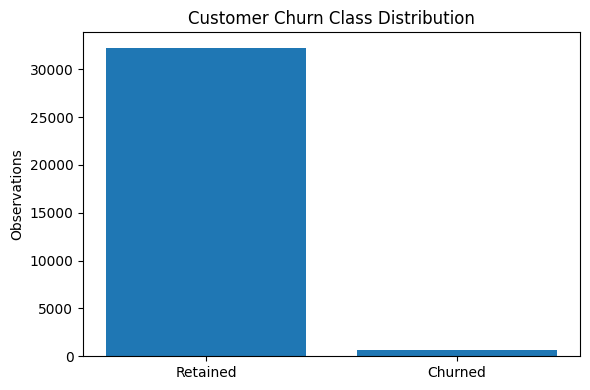

In [53]:
# ============================================================
# 18. PLOTS
# ============================================================

# ------------------------------------------------------------
# Plot 1: Target imbalance
# ------------------------------------------------------------

target_counts = (
    df["is_churn"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(6, 4))
plt.bar(
    ["Retained", "Churned"],
    target_counts.values
)
plt.title("Customer Churn Class Distribution")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()


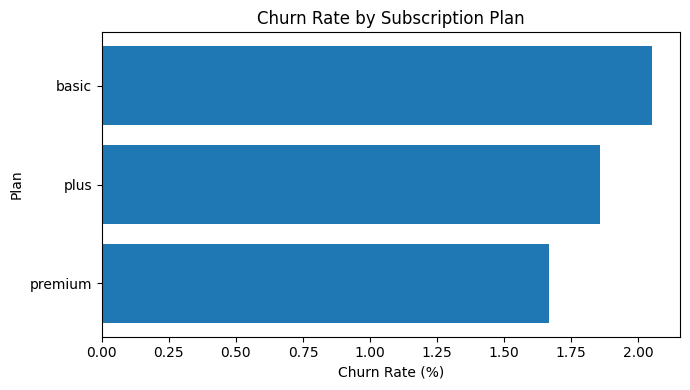

In [54]:
# ------------------------------------------------------------
# Plot 2: Churn rate by plan
# ------------------------------------------------------------

plot_data = plan_churn.sort_values(
    "churn_rate"
)

plt.figure(figsize=(7, 4))
plt.barh(
    plot_data.index,
    plot_data["churn_rate_pct"]
)
plt.xlabel("Churn Rate (%)")
plt.ylabel("Plan")
plt.title("Churn Rate by Subscription Plan")
plt.tight_layout()
plt.show()



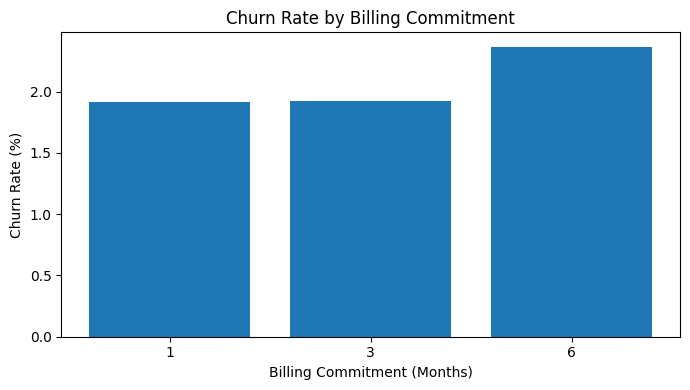

In [55]:
# ------------------------------------------------------------
# Plot 3: Churn rate by billing period
# ------------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.bar(
    billing_churn.index.astype(str),
    billing_churn["churn_rate_pct"]
)
plt.xlabel("Billing Commitment (Months)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Billing Commitment")
plt.tight_layout()
plt.show()

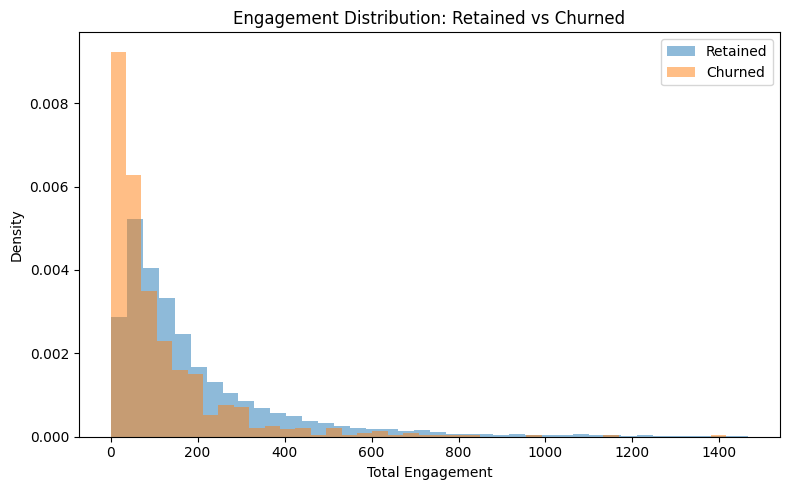

In [56]:
# ------------------------------------------------------------
# Plot 4: Engagement distribution
# Limit visual to 99th percentile because of long tail
# ------------------------------------------------------------

engagement_limit = df["total_engagement"].quantile(0.99)

plt.figure(figsize=(8, 5))

for churn_value, label in [
    (0, "Retained"),
    (1, "Churned")
]:
    subset = df.loc[
        (df["is_churn"] == churn_value)
        & (df["total_engagement"] <= engagement_limit),
        "total_engagement"
    ]

    plt.hist(
        subset,
        bins=40,
        alpha=0.5,
        label=label,
        density=True
    )

plt.xlabel("Total Engagement")
plt.ylabel("Density")
plt.title("Engagement Distribution: Retained vs Churned")
plt.legend()
plt.tight_layout()
plt.show()


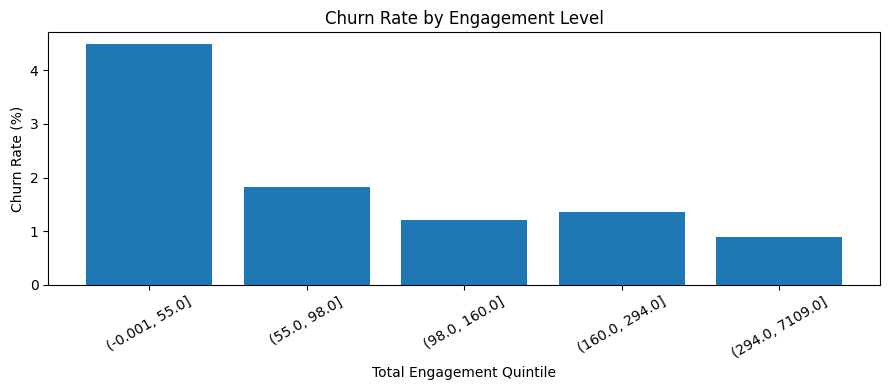

In [57]:
# ------------------------------------------------------------
# Plot 5: Churn by engagement quintile
# ------------------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(
    engagement_churn.index.astype(str),
    engagement_churn["churn_rate_pct"]
)
plt.xlabel("Total Engagement Quintile")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Engagement Level")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


/var/folders/zh/p622gc4n7c9gv5_6pt2mnhb40000gn/T/ipykernel_57155/1043100925.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


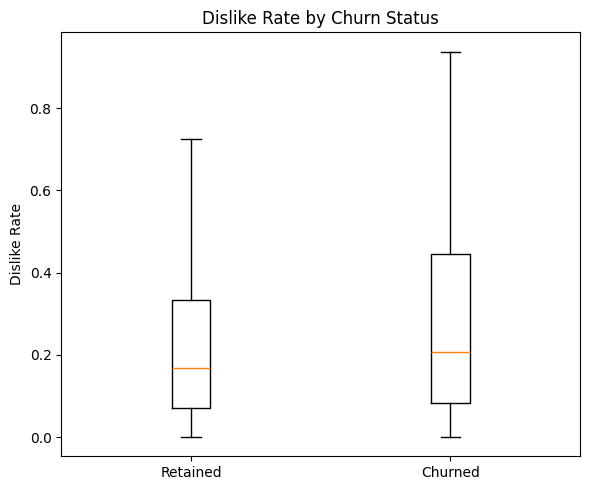

In [58]:

# ------------------------------------------------------------
# Plot 6: Dislike rate by churn status
# ------------------------------------------------------------

plot_values = [
    df.loc[df["is_churn"] == 0, "dislike_rate"],
    df.loc[df["is_churn"] == 1, "dislike_rate"]
]

plt.figure(figsize=(6, 5))
plt.boxplot(
    plot_values,
    labels=["Retained", "Churned"],
    showfliers=False
)
plt.ylabel("Dislike Rate")
plt.title("Dislike Rate by Churn Status")
plt.tight_layout()
plt.show()


/var/folders/zh/p622gc4n7c9gv5_6pt2mnhb40000gn/T/ipykernel_57155/2530566360.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


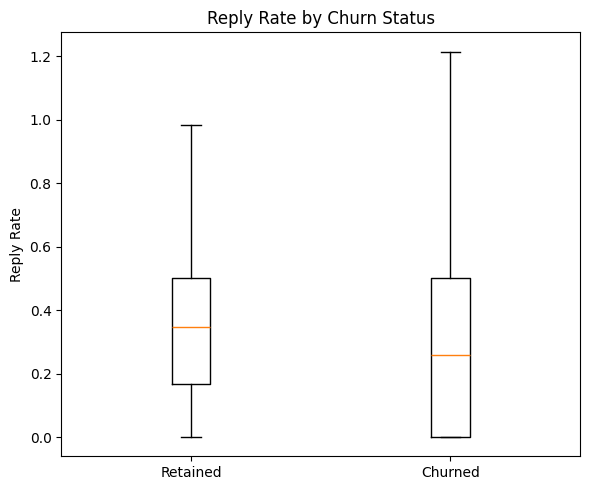

In [59]:
# ------------------------------------------------------------
# Plot 7: Reply rate by churn status
# Cap plot at 99th percentile for readability
# ------------------------------------------------------------

reply_cap = df["reply_rate"].quantile(0.99)

reply_retained = df.loc[
    (df["is_churn"] == 0)
    & (df["reply_rate"] <= reply_cap),
    "reply_rate"
]

reply_churned = df.loc[
    (df["is_churn"] == 1)
    & (df["reply_rate"] <= reply_cap),
    "reply_rate"
]

plt.figure(figsize=(6, 5))
plt.boxplot(
    [reply_retained, reply_churned],
    labels=["Retained", "Churned"],
    showfliers=False
)
plt.ylabel("Reply Rate")
plt.title("Reply Rate by Churn Status")
plt.tight_layout()
plt.show()


In [60]:
# ============================================================
# 19. MODEL FEATURE SET PREVIEW
# ============================================================

# IDs are NOT model features.
# observation_date will later be used for temporal splitting.

categorical_features = [
    "channel",
    "country",
    "current_plan"
]

numeric_features = [
    "customer_age",
    "account_tenure_days",

    # Original behavior
    "post_per_month",
    "newfriend_per_month",
    "like_per_month",
    "adview_per_month",
    "dislike_per_month",
    "unfriend_per_month",
    "message_per_month",
    "reply_per_month",

    # Engineered behavior
    "total_engagement",
    "negative_engagement",
    "total_activity",
    "dislike_rate",
    "unfriend_rate",
    "reply_rate",
    "negative_activity_share",
    "adview_share",

    # Subscription
    "current_mrr",
    "bill_period_months",
    "discount",
    "mrr_change",
    "upgrade_flag",
    "downsell_flag",
    "upgrade_last_90d",
    "downsell_last_90d"
]

model_features = (
    categorical_features
    + numeric_features
)

print("\nNumber of candidate model features:")
print(len(model_features))

print("\nCandidate features:")
for feature in model_features:
    print(feature)


# ============================================================
# 20. FINAL MODELING DATASET
# ============================================================

model_df = df[
    [
        "account_id",
        "observation_date",
        "is_churn"
    ]
    + model_features
].copy()

print("\nFinal modeling dataset shape:")
print(model_df.shape)

print("\nMissing values:")
print(
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

display(model_df.head())




Number of candidate model features:
29

Candidate features:
channel
country
current_plan
customer_age
account_tenure_days
post_per_month
newfriend_per_month
like_per_month
adview_per_month
dislike_per_month
unfriend_per_month
message_per_month
reply_per_month
total_engagement
negative_engagement
total_activity
dislike_rate
unfriend_rate
reply_rate
negative_activity_share
adview_share
current_mrr
bill_period_months
discount
mrr_change
upgrade_flag
downsell_flag
upgrade_last_90d
downsell_last_90d

Final modeling dataset shape:
(32897, 32)

Missing values:
account_id            0
observation_date      0
upgrade_last_90d      0
downsell_flag         0
upgrade_flag          0
mrr_change            0
discount              0
bill_period_months    0
current_mrr           0
adview_share          0
dtype: int64


,account_id,observation_date,is_churn,channel,country,current_plan,customer_age,account_tenure_days,post_per_month,newfriend_per_month,like_per_month,adview_per_month,dislike_per_month,unfriend_per_month,message_per_month,reply_per_month,total_engagement,negative_engagement,total_activity,dislike_rate,unfriend_rate,reply_rate,negative_activity_share,adview_share,current_mrr,bill_period_months,discount,mrr_change,upgrade_flag,downsell_flag,upgrade_last_90d,downsell_last_90d
0,0,2020-03-05,0,appstore2,Unknown,basic,74,53,5,3,146,93,2,0,3,9,166,2,261,0.013514,0.000000,3.000000,0.007663,0.356322,10.0,1,0.0,0.0,0,0,0,0
1,0,2020-04-05,0,appstore2,Unknown,basic,74,84,6,2,140,103,2,0,5,5,158,2,263,0.014085,0.000000,1.000000,0.007605,0.391635,10.0,1,0.0,0.0,0,0,0,0
2,0,2020-05-05,0,appstore2,Unknown,basic,75,114,7,3,141,105,2,0,2,7,160,2,267,0.013986,0.000000,3.500000,0.007491,0.393258,10.0,1,0.0,0.0,0,0,0,0
3,1,2020-03-08,0,appstore1,AU,basic,64,53,30,5,19,27,11,0,11,5,70,11,108,0.366667,0.000000,0.454545,0.101852,0.250000,10.0,1,0.0,0.0,0,0,0,0
4,1,2020-04-08,0,appstore1,AU,basic,64,84,37,8,21,25,8,1,10,2,78,9,112,0.275862,0.111111,0.200000,0.080357,0.223214,10.0,1,0.0,0.0,0,0,0,0


In [61]:
# ============================================================
# 21. SAVE FEATURE-ENGINEERED DATASET
# ============================================================

OUTPUT_PATH = "../data/churn_modeling_ready.csv"

model_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print(
    f"\nSaved modeling dataset to: {OUTPUT_PATH}"
)

print(
    "Shape:",
    model_df.shape
)


Saved modeling dataset to: ../data/churn_modeling_ready.csv
Shape: (32897, 32)
